# 4.1.1 Baseline Convergence and Pseudospectra for 1-Forms (Appendix A.1.1)

Reproduces Table 4.3, Figure 4.1 and Figure 4.2 of the thesis and Figures A.1-A.5 of the appendix
(1-forms on the criss-cross mesh of $(0,\pi)^2$: baseline eigenvalues and $h$/$p$-convergence under
$\beta_0$, and $\varepsilon$-pseudospectra of $A(\mathcal{P}_1)$ and $B(\mathcal{N}^{\mathrm{I}}_1)$
for the $W^{1,\infty}$ winds $\beta_1$, $\beta_2$, $\beta_4$, $\beta_5$). Imports the shared module
`pseudospectra_partial_schur.py` from this folder. Run top to bottom in a kernel with Firedrake, SLEPc and
MUMPS (plus a LaTeX installation: the figure style sets `text.usetex`); figures are written to `./figures`.


## Setup


Plot style and imports (the `pseudospectra_partial_schur` module, table formatting).


In [1]:
import matplotlib.pyplot as plt

# 1. Document parameters
latex_textwidth_pt = 426.79135 # REPLACE with the number you got from \the\textwidth
inches_per_pt = 1.0 / 72.27
fig_width = latex_textwidth_pt * inches_per_pt
fig_height = fig_width * 0.75 # Standard 4:3 aspect ratio, adjust as needed

base_fontsize = 11 # Or 12, depending on your document class declaration

# 2. Update rcParams globally
plt.rcParams.update({
    "figure.figsize": (fig_width, fig_height),
    
    # Match LaTeX fonts
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    
    # Match font sizes exactly
    "font.size": base_fontsize,
    "axes.titlesize": base_fontsize,
    "axes.labelsize": base_fontsize,
    "legend.fontsize": base_fontsize - 1, # Slightly smaller for legend
    "xtick.labelsize": base_fontsize - 2, # Smaller for tick marks
    "ytick.labelsize": base_fontsize - 2,
    
    # Refine line weights for a professional look
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.5,
})

In [2]:
from __future__ import annotations

import itertools
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from firedrake import *
from firedrake.function import PointEvaluator
from firedrake.pyplot import triplot, tripcolor

from petsc4py import PETSc
from slepc4py import SLEPc

# The epsilon-pseudospectrum machinery lives in its own module: it works on
# assembled PETSc matrices and knows nothing about the formulation, so the same
# code serves this notebook and the top-form benchmark.
import pseudospectra_partial_schur as ps

# `from firedrake import *` exports a `logging` of its own, so the standard
# library module has to be re-imported under another name afterwards.
import logging as stdlogging
stdlogging.getLogger("firedrake").setLevel(stdlogging.ERROR)
stdlogging.getLogger("tsfc").setLevel(stdlogging.ERROR)

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
L_DOMAIN = np.pi

# PETSc here is built with REAL scalars: SLEPc returns a complex eigenvector as a
# pair (real part, imaginary part) of separate real vectors.
COMPLEX_PETSC = ps.COMPLEX_PETSC

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "figure.dpi": 110, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "axes.linewidth": 0.6,
})

# Publication style for the pseudospectrum panels, matching the L-shape notebook.
PS_RC = {
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02, "ps.fonttype": 42,
}


# --- table rendering, without pandas' jinja2-dependent .style ----------------
def _cell(value, spec):
    if value is None:
        return "--"
    if isinstance(value, complex):
        return (f"{value.real:.5f}{value.imag:+.5f}i" if abs(value.imag) > 1e-10
                else spec.format(value.real))
    try:
        return "--" if not np.isfinite(value) else spec.format(value)
    except (TypeError, ValueError):
        return str(value)


def fmt_table(df, caption=None, default="{:.6f}", rules=(), row_rules=()):
    """Format a DataFrame for display; `rules` match column names, `row_rules`
    index labels and take precedence."""
    def spec_for(key, table):
        name = " ".join(map(str, key)) if isinstance(key, tuple) else str(key)
        # Exact matches win over substring matches: a rule keyed on "m" must not
        # capture a column called "max |Im ritz|".
        return next((spec for k, spec in table if k == name),
                    next((spec for k, spec in table if k in name), None))

    out = pd.DataFrame(
        {col: [_cell(v, spec_for(idx, row_rules) or spec_for(col, rules) or default)
               for idx, v in zip(df.index, df[col])]
         for col in df.columns}, index=df.index)
    if caption:
        display(Markdown(f"**{caption}**"))
    return out


print(f"PETSc scalars: {PETSc.ScalarType.__name__} "
      f"({'complex' if COMPLEX_PETSC else 'real'} build)")

PETSc scalars: float64 (real build)


Mesh, spaces, pencil assembly, shift-and-invert solver, exact spectrum and exact modes.


In [3]:
def crisscross_mesh(N, L=L_DOMAIN):
    r"""Criss-cross (Union-Jack) triangulation of $(0,L)^2$: $4N^2$ cells, $h = L/N$."""
    return SquareMesh(N, N, L, quadrilateral=False, diagonal="crossed")


def cross2d(a, b):
    """Scalar 2D cross product $(a\\times b)_z = a_1b_2 - a_2b_1$; antisymmetric,
    so the ordering in the induction term (`cross2d(v, u)`) is load-bearing."""
    return a[0] * b[1] - a[1] * b[0]


def space(form, mesh, p):
    if form == "A(CG)":
        return FunctionSpace(mesh, "CG", p)
    if form == "B(N1)":
        return FunctionSpace(mesh, "N1curl", p) * FunctionSpace(mesh, "CG", p)
    return FunctionSpace(mesh, "N2curl", p) * FunctionSpace(mesh, "CG", p + 1)


FORMS = ["A(CG)", "B(N1)", "B(N2)"]
STYLE = {"A(CG)": ("C2", "^"), "B(N1)": ("C0", "o"), "B(N2)": ("C1", "s")}

In [4]:
def to_scipy(mat):
    indptr, indices, data = mat.getValuesCSR()
    return sp.csr_matrix((data, indices, indptr), shape=mat.getSize())


def to_petsc(S):
    S = sp.csr_matrix(S); S.sort_indices()
    return PETSc.Mat().createAIJWithArrays(
        S.shape, (S.indptr.astype(PETSc.IntType),
                  S.indices.astype(PETSc.IntType), S.data))


def build_pencil(form, mesh, p=1, beta=None, eps=Constant(1.0)):
    r"""Assemble $(A, M)$ for one formulation. $M$ is singular in every case."""
    if form == "A(CG)":
        V = space(form, mesh, p)
        a_, z = TrialFunction(V), TestFunction(V)
        a = eps * inner(grad(a_), grad(z)) * dx
        if beta is not None:
            a += inner(dot(beta, grad(a_)), z) * dx
        K = assemble(a).petscmat
        M = assemble(inner(a_, z) * dx).petscmat
        # g_i = \int phi_i : the gauge constraint \int A = 0 as a rank-one border,
        #   [[K, -g], [-g^T, 0]] x = lambda [[M, 0], [0, 0]] x.
        g = np.asarray(assemble(TestFunction(V) * dx).dat.data_ro).copy()
        col = sp.csr_matrix(-g.reshape(-1, 1))
        A_b = sp.bmat([[to_scipy(K), col], [col.T, None]], format="csr")
        M_b = sp.bmat([[to_scipy(M), None], [None, sp.csr_matrix((1, 1))]],
                      format="csr")
        return to_petsc(A_b), to_petsc(M_b), V

    W = space(form, mesh, p)
    (v, q) = TrialFunctions(W)
    (w, r) = TestFunctions(W)
    a = eps * inner(curl(v), curl(w)) * dx
    if beta is not None:
        a += inner(cross2d(v, beta), curl(w)) * dx
    a += (-inner(grad(q), w) + inner(v, grad(r))) * dx
    # DirichletBC on an H(curl) space constrains the TANGENTIAL trace, i.e. the
    # perfectly-conducting condition; p = 0 puts the multiplier in CG \cap H^1_0.
    bcs = [DirichletBC(W.sub(0), Constant((0.0, 0.0)), "on_boundary"),
           DirichletBC(W.sub(1), Constant(0.0), "on_boundary")]
    # weight=0.0 gives the constrained rows a zero mass diagonal, so the boundary
    # modes go to lambda = infinity rather than to a spurious lambda = 1.
    return (assemble(a, bcs=bcs).petscmat,
            assemble(inner(v, w) * dx, bcs=bcs, weight=0.0).petscmat, W)

In [5]:
EPS_OPTS = {
    "eps_gen_non_hermitian": None,
    "eps_type": "krylovschur",
    "eps_target_magnitude": None,
    "eps_tol": 1e-12,
    "eps_max_it": 5000,
    "st_type": "sinvert",
    "st_ksp_type": "preonly",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 800,
}
_prefix = itertools.count()
KAPPA_LOG = []


def shifted_matrix(A, M, sigma):
    S = A.copy()
    S.axpy(-sigma, M, structure=PETSc.Mat.Structure.DIFFERENT_NONZERO_PATTERN)
    return S


def condition_estimates(A, M, sigma):
    r"""Estimates of $\kappa(A-\sigma M)$: normwise $\kappa_1$, and MUMPS' COND1."""
    S = shifted_matrix(A, M, sigma)

    ksp = PETSc.KSP().create(comm=S.getComm())
    ksp.setOperators(S); ksp.setType("preonly")
    pc = ksp.getPC(); pc.setType("lu"); pc.setFactorSolverType("mumps")
    # The factor Mat has to exist before the numeric factorisation for ICNTL(11)
    # to take effect; the error analysis itself runs during the solve.
    pc.setFactorSetUpSolverType()
    F = pc.getFactorMatrix()
    F.setMumpsIcntl(11, 1)
    F.setMumpsIcntl(14, 800)
    ksp.setUp()
    b, xv = S.createVecLeft(), S.createVecRight()
    b.set(1.0)
    ksp.solve(b, xv)
    cond1, infog1 = F.getMumpsRinfog(10), F.getMumpsInfog(1)
    ksp.destroy()

    Ssp = to_scipy(S).tocsc()
    lu = spla.splu(Ssp)
    n = Ssp.shape[0]
    inverse = spla.LinearOperator(
        (n, n), matvec=lu.solve, rmatvec=lambda v: lu.solve(v, trans="T"))
    kappa1 = spla.onenormest(Ssp) * spla.onenormest(inverse)
    return {r"Hager $\kappa_1$": kappa1, "MUMPS COND1": cond1, "INFOG(1)": infog1}


@dataclass
class Result:
    values: np.ndarray
    index: np.ndarray
    solver: object
    A: object
    space: object
    form: str
    ndof: int
    kappa: dict

    @property
    def real(self):
        return self.values.real

    @property
    def kappa1(self):
        return self.kappa[r"Hager $\kappa_1$"]


#: Eigenvalues above this are the multiplier block's modes at infinity, returned
#: as large finite numbers by an ill-conditioned coarse pencil.  The resolved
#: spectrum here is O(10^2), so the gap is wide and the threshold uncritical.
INF_TOL = 1e6


def solve_eigs(form, mesh, p=1, beta=None, Rm=1.0, tau=None, nev=25, cond=True):
    r"""Shift-and-invert solve for one configuration, with $\kappa(A-\tau M)$ attached.

    `tau` defaults to $0.9\varepsilon$, just below the first Maxwell eigenvalue
    $\lambda_1 = \varepsilon$; that keeps the wanted end of the spectrum nearest
    the shift without ever sitting on it.
    """
    eps = Constant(1.0 / Rm)
    tau = 0.9 / Rm if tau is None else tau
    A, M, W = build_pencil(form, mesh, p, beta=beta, eps=eps)

    opts = dict(EPS_OPTS, eps_target=tau,
                eps_ncv=min(2 * nev + 30, A.getSize()[0]))
    prefix = f"bl{next(_prefix)}_"
    db = PETSc.Options()
    for k, v in opts.items():
        db[prefix + k] = v
    solver = SLEPc.EPS().create(comm=A.getComm())
    solver.setOptionsPrefix(prefix)
    solver.setOperators(A, M)
    solver.setDimensions(nev=nev)
    solver.setFromOptions()
    solver.solve()
    for k in opts:
        db.delValue(prefix + k)

    found = []
    for i in range(solver.getConverged()):
        z = complex(solver.getEigenvalue(i))
        if np.isfinite(z) and 1e-9 < abs(z) < INF_TOL:
            found.append((i, z))
    found.sort(key=lambda t: (t[1].real, abs(t[1].imag)))

    kappa = condition_estimates(A, M, tau) if cond else None
    if kappa is not None:
        KAPPA_LOG.append(dict(form=form, p=p, N=mesh.num_cells(), Rm=Rm,
                              tau=tau, **kappa))
    return Result(np.array([z for _, z in found]),
                  np.array([i for i, _ in found]), solver, A, W, form,
                  A.getSize()[0], kappa)


def eigenfunction(res, k):
    """The k-th eigenmode: the H(curl) field for B(...), the potential for A(CG)."""
    vr, vi = res.A.createVecRight(), res.A.createVecRight()
    res.solver.getEigenvector(int(res.index[k]), vr, vi)
    arr = np.asarray(vr.getArray())
    if res.form == "A(CG)":
        f = Function(res.space)
        f.dat.data[:] = arr[:res.space.dim()]
        return f
    f = Function(res.space)
    with f.dat.vec_wo as fv:
        fv.setArray(arr[:fv.getLocalSize()])
    return f.subfunctions[0]


def exact_spectrum(n, Rm=1.0, kmax=30):
    r"""$\varepsilon(m^2+n^2)$, $m,n\ge0$, $(m,n)\ne(0,0)$, with multiplicity."""
    vals = sorted(m * m + k * k for m in range(kmax) for k in range(kmax)
                  if (m, k) != (0, 0))
    return np.array(vals[:n], dtype=float) / Rm


#: The exact eigenvalue *clusters* covering the first five eigenvalues, each with
#: the index pairs $(m,n)$ whose potential $\cos(mx)\cos(ny)$ spans its eigenspace.
#: Clusters rather than individual modes because $\lambda = 1$ and $\lambda = 4$
#: are double: on a degenerate eigenspace the computed eigenvector is only defined
#: up to a rotation within the space, so a vector-by-vector error is meaningless.
CLUSTERS = [(1.0, [(1, 0), (0, 1)]),
            (2.0, [(1, 1)]),
            (4.0, [(2, 0), (0, 2)])]
N_TRACK = 5          # eigenvalues followed individually in the convergence study


def exact_field(mesh, m, n):
    r"""$B = \nabla\times\cos(mx)\cos(ny) = (-n\cos mx\,\sin ny,\ m\sin mx\,\cos ny)$."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([-n * cos(m * x) * sin(n * y),
                      m * sin(m * x) * cos(n * y)])

## Table 4.3: Baseline 1-form eigenvalues under β0


First five eigenvalues of the three formulations against the non-zero Neumann eigenvalues, with DoF counts and MUMPS `COND1` of $A-\tau M$. $\beta_0$, $R_m=1$, criss-cross $N=64$, $p=3$, $\tau=0.9$, 100 eigenvalues. The second cell prints the same table to 15 decimals.


In [6]:
N_FINE, P_BASE = 64, 3
mesh_fine = crisscross_mesh(N_FINE)

runs0 = {f: solve_eigs(f, mesh_fine, p=P_BASE, nev=100) for f in FORMS}
ex5 = exact_spectrum(5)

# 1. Build the core eigenvalues data (no relative errors)
data = {r"True $\lambda_{ref}$": ex5}
for f in FORMS:
    data[f] = runs0[f].real[:5]

tbl = pd.DataFrame(data)

# 2. Append the condition number row, labeled exactly as in the screenshot
# We are feeding it the MUMPS COND1 data here as requested
tbl.loc[r"$\kappa(A-\tau M)$"] = [np.nan] + [runs0[f].kappa['MUMPS COND1'] for f in FORMS]

# 3. Create a MultiIndex for the columns to match the 3-tier header in the image
TEX = {
    "B(N1)": rf"$B(\mathcal{{N}}^{{\mathrm{{I}}}}_{{{P_BASE}}})$", 
    "B(N2)": rf"$B(\mathcal{{N}}^{{\mathrm{{II}}}}_{{{P_BASE}}})$", 
    "A(P)": rf"$A(\mathcal{{P}}_{{{P_BASE}}})$"
}

# The first column gets the leftmost labels stacked vertically
col_tuples = [("Formulation", "DoF", r"True $\lambda_{ref}$")]

# The remaining columns get the LaTeX formulation, the DoF count, and \lambda_h
for f in FORMS:
    dof_str = f"{runs0[f].ndof:,}" # Format with a comma for thousands
    col_tuples.append((TEX.get(f, f), dof_str, r"$\lambda_h$"))
    
tbl.columns = pd.MultiIndex.from_tuples(col_tuples)

# 4. Render with fmt_table
fmt_table(tbl, 
          # Format True reference to 4 decimal places, and computed to 6
          rules=[(r"True", "{:.4f}"), (r"\lambda_h", "{:.6f}")],
          row_rules=[(r"\kappa", "{:.2e}")],
          caption=rf"First five eigenvalues, $\beta_0 = 0$, $p = {P_BASE}$, criss-cross "
                  rf"$N = {N_FINE}$ ($h = \pi/{N_FINE}$, {mesh_fine.num_cells()} cells)")

print("self-adjointness check (u = 0 must give a real spectrum):")
for f in FORMS:
    v = runs0[f].values[:20]
    print(f"  {f:7s} max |Im lambda| = {np.abs(v.imag).max():.3e}"
          f"    MUMPS COND1 = {runs0[f].kappa['MUMPS COND1']:.2e}"
          f"    INFOG(1) = {runs0[f].kappa['INFOG(1)']}")

**First five eigenvalues, $\beta_0 = 0$, $p = 3$, criss-cross $N = 64$ ($h = \pi/64$, 16384 cells)**

self-adjointness check (u = 0 must give a real spectrum):
  A(CG)   max |Im lambda| = 0.000e+00    MUMPS COND1 = 2.54e+03    INFOG(1) = 0
  B(N1)   max |Im lambda| = 0.000e+00    MUMPS COND1 = 2.40e+05    INFOG(1) = 0
  B(N2)   max |Im lambda| = 0.000e+00    MUMPS COND1 = 2.39e+05    INFOG(1) = 0


In [7]:
display(fmt_table(tbl, 
          rules=[(r"True", "{:.4f}"), (r"\lambda_h", "{:.15f}")],
          row_rules=[(r"\kappa", "{:.2e}")],
          caption=rf"First five eigenvalues, $\beta_0 = 0$, $p = {P_BASE}$, criss-cross "
                  rf"$N = {N_FINE}$ ($h = \pi/{N_FINE}$, {mesh_fine.num_cells()} cells)"))

**First five eigenvalues, $\beta_0 = 0$, $p = 3$, criss-cross $N = 64$ ($h = \pi/64$, 16384 cells)**

,Formulation,A(CG),$B(\mathcal{N}^{\mathrm{I}}_{3})$,$B(\mathcal{N}^{\mathrm{II}}_{3})$
,DoF,"74,114","246,529","361,473"
,True $\lambda_{ref}$,$\lambda_h$,$\lambda_h$,$\lambda_h$
0,1.0000,0.999999999998259,1.000000000006576,1.000000000003030
1,1.0000,0.999999999999249,1.000000000008154,1.000000000004273
2,2.0000,1.999999999998967,2.000000000007219,2.000000000004144
3,4.0000,4.000000000006793,4.000000000010351,4.000000000008100
4,4.0000,4.000000000007138,4.000000000011629,4.000000000008737
$\kappa(A-\tau M)$,--,2.54e+03,2.40e+05,2.39e+05


## Figure 4.1: A(P_p) convergence under h- and p-refinement (β0)


$h$-refinement ($p=1$, $N\in\{4,8,16,32,64\}$; $p=2$, $N\in\{4,8,16,32\}$) and $p$-refinement ($N=6$, $p=1,\dots,5$) studies of the first five eigenvalues for all three formulations ($\beta_0$, $R_m=1$, $\tau=0.9$, 25 eigenvalues). The tables record the observed rates and `COND1`; Figures A.1 and A.2 draw from the same studies. Panels: `baseline_h_p1_ACG.eps`, `baseline_pref_ACG.eps`.


In [8]:
# The exact modes are trigonometric, so error integrals use a fixed high-order
# rule rather than UFL's degree estimate.
DX_HI = dx(metadata={"quadrature_degree": 10})

def rates(h, e):
    """Observed order between consecutive refinement levels."""
    h, e = np.asarray(h, float), np.asarray(e, float)
    r = np.full(e.shape, np.nan)
    with np.errstate(divide="ignore", invalid="ignore"):
        r[1:] = np.log(e[:-1] / e[1:]) / np.log(h[:-1] / h[1:])
    return r


def as_field(form, f):
    r"""The magnetic field of an eigenmode: $\nabla\times A_h$, or $v_h$ itself."""
    return as_vector([f.dx(1), -f.dx(0)]) if form == "A(CG)" else f


def _whiten(G):
    """W with W^T G W = I, dropping numerically null directions.

    An eigendecomposition rather than a Cholesky: the computed basis of a cluster
    can be close to rank deficient on coarse meshes, where a Cholesky simply
    fails.
    """
    w, V = np.linalg.eigh(G)
    keep = w > w.max() * 1e-13
    return V[:, keep] / np.sqrt(w[keep])


def subspace_error(computed, exact):
    r"""$\sin\theta_{\max}$ between two $L^2$ subspaces (the gap).

    With orthonormalised bases the singular values of the cross-Gram matrix are
    the cosines of the principal angles, so the largest angle is set by the
    smallest singular value.  Equals the usual normalised $L^2$ error, up to
    sign, when both subspaces are one-dimensional.
    """
    gram = lambda P, Q: np.array([[assemble(inner(a, b) * DX_HI) for b in Q]
                                  for a in P])
    Wc, We = _whiten(gram(computed, computed)), _whiten(gram(exact, exact))
    sv = np.linalg.svd(Wc.T @ gram(computed, exact) @ We, compute_uv=False)
    return float(np.sqrt(max(0.0, 1.0 - min(sv.min(), 1.0) ** 2)))


def h_study(form, p, levels, with_fields=False):
    """Eigenvalue errors for the first `N_TRACK` modes, and optionally the
    eigenspace gaps, over a sequence of meshes."""
    exact = exact_spectrum(N_TRACK)
    rows_e, rows_f = [], []
    for N in levels:
        mesh = crisscross_mesh(N)
        res = solve_eigs(form, mesh, p=p, nev=25)
        lam = res.real
        rows_e.append(dict(N=N, h=np.pi / N, dof=res.ndof,
                           **{rf"$\lambda_{{{j+1}}}$": abs(lam[j] - exact[j]) / exact[j]
                              for j in range(N_TRACK)},
                           **{"MUMPS COND1": res.kappa["MUMPS COND1"]}))
        if with_fields:
            row = dict(N=N, h=np.pi / N)
            for value, modes in CLUSTERS:
                # Selected by proximity to the exact cluster, not by position:
                # robust to any reordering of the computed spectrum.
                idx = np.argsort(np.abs(lam - value))[:len(modes)]
                row[rf"$\lambda={value:g}$"] = subspace_error(
                    [as_field(form, eigenfunction(res, int(i))) for i in idx],
                    [exact_field(mesh, m, n) for m, n in modes])
            row["MUMPS COND1"] = res.kappa["MUMPS COND1"]
            rows_f.append(row)

    df_e = pd.DataFrame(rows_e).set_index("N")
    df_f = pd.DataFrame(rows_f).set_index("N") if with_fields else None
    return df_e, df_f

In [9]:
H_LEVELS = {1: (4, 8, 16, 32, 64), 2: (4, 8, 16, 32)}
h_eig, h_fun = {}, {}
for p in (1, 2):
    for f in FORMS:
        h_eig[(f, p)], fields = h_study(f, p, H_LEVELS[p], with_fields=(p == 1))
        if fields is not None:
            h_fun[f] = fields

In [10]:
def rate_frame(df, cols):
    """Interleave each error column with its observed rate."""
    out = pd.DataFrame(index=df.index)
    out["h"] = df["h"]
    for c in cols:
        out[c] = df[c]
        out[f"rate {c}"] = rates(df["h"], df[c])
    out["MUMPS COND1"] = df["MUMPS COND1"]
    return out


EIG_COLS = [rf"$\lambda_{{{j+1}}}$" for j in range(N_TRACK)]
for p in (1, 2):
    for f in FORMS:
        display(fmt_table(
            rate_frame(h_eig[(f, p)], EIG_COLS), default="{:.3e}",
            rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), ("MUMPS COND1", "{:.2e}")],
            caption=rf"$h$-refinement, **{f}**, $p = {p}$: relative error in the first "
                    rf"{N_TRACK} eigenvalues, expected rate $2p = {2*p}$"))

**$h$-refinement, **A(CG)**, $p = 1$: relative error in the first 5 eigenvalues, expected rate $2p = 2$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,MUMPS COND1
N,,,,,,,,,,,,
4,0.78540,3.457e-02,--,3.457e-02,--,4.401e-02,--,1.402e-01,--,1.402e-01,--,4.92e+01
8,0.39270,8.587e-03,2.01,8.587e-03,2.01,1.078e-02,2.03,3.457e-02,2.02,3.457e-02,2.02,8.21e+01
16,0.19635,2.143e-03,2.00,2.143e-03,2.00,2.682e-03,2.01,8.587e-03,2.01,8.587e-03,2.01,1.39e+02
32,0.09817,5.355e-04,2.00,5.355e-04,2.00,6.696e-04,2.00,2.143e-03,2.00,2.143e-03,2.00,2.50e+02
64,0.04909,1.339e-04,2.00,1.339e-04,2.00,1.673e-04,2.00,5.355e-04,2.00,5.355e-04,2.00,4.72e+02


**$h$-refinement, **B(N1)**, $p = 1$: relative error in the first 5 eigenvalues, expected rate $2p = 2$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,MUMPS COND1
N,,,,,,,,,,,,
4,0.78540,4.164e-03,--,4.164e-03,--,1.726e-02,--,1.505e-02,--,1.505e-02,--,6.92e+02
8,0.39270,1.064e-03,1.97,1.064e-03,1.97,4.291e-03,2.01,4.164e-03,1.85,4.164e-03,1.85,2.57e+03
16,0.19635,2.673e-04,1.99,2.673e-04,1.99,1.071e-03,2.00,1.064e-03,1.97,1.064e-03,1.97,4.99e+03
32,0.09817,6.690e-05,2.00,6.690e-05,2.00,2.678e-04,2.00,2.673e-04,1.99,2.673e-04,1.99,9.67e+03
64,0.04909,1.673e-05,2.00,1.673e-05,2.00,6.693e-05,2.00,6.690e-05,2.00,6.690e-05,2.00,2.78e+04


**$h$-refinement, **B(N2)**, $p = 1$: relative error in the first 5 eigenvalues, expected rate $2p = 2$**

...

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,MUMPS COND1
N,,,,,,,,,,,,
4,0.78540,2.049e-04,--,2.049e-04,--,4.279e-04,--,3.014e-03,--,3.014e-03,--,1.07e+02
8,0.39270,1.311e-05,3.97,1.311e-05,3.97,2.773e-05,3.95,2.049e-04,3.88,2.049e-04,3.88,1.79e+02
16,0.19635,8.241e-07,3.99,8.241e-07,3.99,1.749e-06,3.99,1.311e-05,3.97,1.311e-05,3.97,3.26e+02
32,0.09817,5.158e-08,4.00,5.158e-08,4.00,1.096e-07,4.00,8.241e-07,3.99,8.241e-07,3.99,6.20e+02


**$h$-refinement, **B(N1)**, $p = 2$: relative error in the first 5 eigenvalues, expected rate $2p = 4$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,MUMPS COND1
N,,,,,,,,,,,,
4,0.78540,5.970e-05,--,5.970e-05,--,2.940e-05,--,8.990e-04,--,8.990e-04,--,4.25e+03
8,0.39270,3.788e-06,3.98,3.788e-06,3.98,1.974e-06,3.90,5.970e-05,3.91,5.970e-05,3.91,1.37e+04
16,0.19635,2.377e-07,3.99,2.377e-07,3.99,1.255e-07,3.98,3.788e-06,3.98,3.788e-06,3.98,1.70e+04
32,0.09817,1.487e-08,4.00,1.487e-08,4.00,7.874e-09,3.99,2.377e-07,3.99,2.377e-07,3.99,4.56e+04


**$h$-refinement, **B(N2)**, $p = 2$: relative error in the first 5 eigenvalues, expected rate $2p = 4$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,MUMPS COND1
N,,,,,,,,,,,,
4,0.78540,9.724e-05,--,9.724e-05,--,3.079e-04,--,1.474e-03,--,1.474e-03,--,2.51e+03
8,0.39270,6.164e-06,3.98,6.164e-06,3.98,1.967e-05,3.97,9.724e-05,3.92,9.724e-05,3.92,2.76e+03
16,0.19635,3.866e-07,3.99,3.866e-07,3.99,1.236e-06,3.99,6.164e-06,3.98,6.164e-06,3.98,8.43e+03
32,0.09817,2.418e-08,4.00,2.418e-08,4.00,7.738e-08,4.00,3.866e-07,3.99,3.866e-07,3.99,2.70e+04


In [11]:
P_LEVELS = (1, 2, 3, 4, 5)
N_PREF = 6


def p_study(form, levels=P_LEVELS, N=N_PREF):
    exact = exact_spectrum(N_TRACK)
    rows = []
    for p in levels:
        res = solve_eigs(form, crisscross_mesh(N), p=p, nev=25)
        lam = res.real
        rows.append(dict(p=p, dof=res.ndof,
                         **{rf"$\lambda_{{{j+1}}}$": abs(lam[j] - exact[j]) / exact[j]
                            for j in range(N_TRACK)},
                         **{"MUMPS COND1": res.kappa["MUMPS COND1"]}))
    return pd.DataFrame(rows).set_index("p")


p_tables = {f: p_study(f) for f in FORMS}
for f in FORMS:
    display(fmt_table(
        p_tables[f], default="{:.3e}",
        rules=[("dof", "{:.0f}"), ("MUMPS COND1", "{:.2e}")],
        caption=rf"$p$-refinement, **{f}**, fixed $N = {N_PREF}$: relative error in the "
                rf"first {N_TRACK} eigenvalues"))

**$p$-refinement, **A(CG)**, fixed $N = 6$: relative error in the first 5 eigenvalues**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,MUMPS COND1
p,,,,,,,
1,86,1.529e-02,1.529e-02,1.927e-02,6.178e-02,6.178e-02,6.65e+01
2,314,4.117e-05,4.117e-05,8.679e-05,6.329e-04,6.329e-04,1.43e+02
3,686,4.702e-08,4.702e-08,1.455e-07,2.982e-06,2.982e-06,2.68e+02
4,1202,4.058e-11,4.058e-11,1.611e-10,1.013e-08,1.013e-08,4.63e+02
5,1862,5.818e-14,7.927e-14,1.270e-13,2.199e-11,2.199e-11,7.65e+02


**$p$-refinement, **B(N1)**, fixed $N = 6$: relative error in the first 5 eigenvalues**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,MUMPS COND1
p,,,,,,,
1,313,1.880e-03,1.880e-03,7.639e-03,7.229e-03,7.229e-03,1.52e+03
2,1057,1.193e-05,1.193e-05,6.128e-06,1.857e-04,1.857e-04,8.56e+03
3,2233,2.035e-08,2.035e-08,2.972e-08,1.276e-06,1.276e-06,1.15e+04
4,3841,1.906e-11,1.910e-11,4.261e-11,4.836e-09,4.836e-09,9.56e+03
5,5881,1.166e-13,1.843e-14,2.220e-16,1.168e-11,1.169e-11,1.22e+04


**$p$-refinement, **B(N2)**, fixed $N = 6$: relative error in the first 5 eigenvalues**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,MUMPS COND1
p,,,,,,,
1,769,7.603e-03,7.603e-03,1.524e-02,3.023e-02,3.023e-02,1.03e+03
2,1801,1.941e-05,1.941e-05,6.181e-05,3.030e-04,3.030e-04,1.46e+03
3,3265,2.660e-08,2.660e-08,1.158e-07,1.670e-06,1.670e-06,1.23e+04
4,5161,2.240e-11,2.244e-11,1.226e-10,5.684e-09,5.684e-09,2.10e+04
5,7489,2.132e-14,4.796e-14,8.371e-14,1.305e-11,1.306e-11,3.09e+04


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


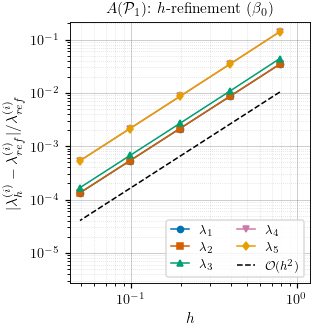

In [12]:
from matplotlib.ticker import LogLocator, NullFormatter
import numpy as np
import matplotlib.pyplot as plt

# 1. Give it a taller aspect ratio (square-ish) so the data has vertical room
half_width = fig_width * 0.49
half_height = half_width * 1.05 

df = h_eig[("A(CG)", 1)]
h = df["h"].to_numpy()
e1 = df[r"$\lambda_{1}$"].to_numpy()
e2 = df[r"$\lambda_{2}$"].to_numpy()
e3 = df[r"$\lambda_{3}$"].to_numpy()
e4 = df[r"$\lambda_{4}$"].to_numpy()
e5 = df[r"$\lambda_{5}$"].to_numpy()

colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']

fig, ax = plt.subplots(figsize=(half_width, half_height))

ax.loglog(h, e1, marker="o", color=colors[0], ms=4.0, lw=1.0, label=r"$\lambda_{1}$")
ax.loglog(h, e2, marker="s", color=colors[1], ms=4.0, lw=1.0, label=r"$\lambda_{2}$")
ax.loglog(h, e3, marker="^", color=colors[2], ms=4.0, lw=1.0, label=r"$\lambda_{3}$")
ax.loglog(h, e4, marker="v", color=colors[3], ms=4.0, lw=1.0, label=r"$\lambda_{4}$")
ax.loglog(h, e5, marker="d", color=colors[4], ms=4.0, lw=1.0, label=r"$\lambda_{5}$")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.0, label=r"$\mathcal{O}(h^{2})$")

# Flatten the y-label fraction and slightly reduce label font sizes for the subfigure
sub_fontsize = base_fontsize - 1 
ax.set_xlabel(r"$h$", fontsize=sub_fontsize)
ax.set_ylabel(r"$|\lambda_h^{(i)} - \lambda_{ref}^{(i)}| / \lambda_{ref}^{(i)}$", fontsize=sub_fontsize)

# Reverted the title pad back to default since the legend is moving back inside
ax.set_title(r"$A(\mathcal{P}_1)$: $h$-refinement ($\beta_0$)", fontsize=sub_fontsize)

ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

locmin = LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12)
ax.xaxis.set_minor_locator(locmin)
ax.xaxis.set_minor_formatter(NullFormatter())

# FORCE 10^0 ON X-AXIS: Extend the right limit slightly past 1.0 so the tick label isn't hidden
ax.set_xlim(right=1.2) 

# 2. Grabs the current limits and stretches the bottom down by a factor of 10
ymin, ymax = ax.get_ylim()
ax.set_ylim(bottom=ymin * 0.1) 

# 3. Compact the legend and tuck it into the newly created space in the lower right
ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray", 
          ncol=2, loc="lower right", handlelength=1.5, borderpad=0.4)

# 4. Use a smaller pad in tight_layout to maximize axis space
plt.tight_layout(pad=0.3)
fig.savefig(FIGDIR / "baseline_h_p1_ACG.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


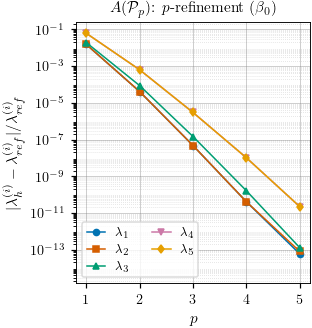

In [13]:
from matplotlib.ticker import LogLocator, NullFormatter

df = p_tables["A(CG)"]

colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']

fig, ax = plt.subplots(figsize=(half_width, half_height))

ax.semilogy(df.index, df[r"$\lambda_{1}$"], marker="o", color=colors[0], ms=4.0, lw=1.0, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[r"$\lambda_{2}$"], marker="s", color=colors[1], ms=4.0, lw=1.0, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[r"$\lambda_{3}$"], marker="^", color=colors[2], ms=4.0, lw=1.0, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[r"$\lambda_{4}$"], marker="v", color=colors[3], ms=4.0, lw=1.0, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[r"$\lambda_{5}$"], marker="d", color=colors[4], ms=4.0, lw=1.0, label=r"$\lambda_{5}$")

sub_fontsize = base_fontsize - 1 
ax.set_xlabel(r"$p$", fontsize=sub_fontsize)
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"$|\lambda_h^{(i)} - \lambda_{ref}^{(i)}| / \lambda_{ref}^{(i)}$", fontsize=sub_fontsize)

ax.set_title(rf"$A(\mathcal{{P}}_p)$: $p$-refinement ($\beta_0$)", fontsize=sub_fontsize)

ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

# Force y-axis minor ticks to display across a deep exponential drop
locmin = LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=40)
ax.yaxis.set_minor_locator(locmin)
ax.yaxis.set_minor_formatter(NullFormatter())

ymin, ymax = ax.get_ylim()
ax.set_ylim(bottom=ymin * 0.1) 

ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray", 
          ncol=2, loc="lower left", handlelength=1.5, borderpad=0.4)

plt.tight_layout(pad=0.3)
fig.savefig(FIGDIR / "baseline_pref_ACG.eps")
plt.show()

## Figure 4.2: 1-form pseudospectra for β4: A(P1) vs. B(N1^I)


Pseudospectra setup: winds $\beta_1,\beta_2,\beta_4,\beta_5$, the $H^1$ metric for $A(\mathcal{P}_1)$, projection of every (formulation, wind) pencil at $R_m=1$, $N=32$, $p=1$, $\tau=0.9$, 100 eigenvalues, then the shared axes and colour scales. The last cell draws $A(\mathcal{P}_1)$ and $B(\mathcal{N}^{\mathrm{I}}_1)$ side by side for $\beta_4$: `baseline_pseudo_b4_sidebyside.eps` (parameter re-run of the $\beta_5$ cell under Figure A.5).


In [14]:
def wind_b1(mesh):
    """beta_1 = (1, 1): constant field."""
    return as_vector([1, 1])

def wind_b2(mesh):
    """beta_2 = (x, -y): linear, solenoidal, and a gradient field."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([x, -y])

def wind_b4(mesh):
    """beta_4 = (-y, x): rigid rotation about the origin; solenoidal, not a gradient."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([-y, x])

def wind_b5(mesh):
    """beta_5 = (x+y, x*y): non-solenoidal field."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([x+y, x*y])

PS_WINDS = {
    "b1": (r"$\beta_1=(1,\,1)$", wind_b1, "constant field"),
    "b2": (r"$\beta_2=(x,\,-y)$", wind_b2, "gradient field"),
    "b4": (r"$\beta_4=(-y,\,x)$", wind_b4, "rigid rotation"),
    "b5": (r"$\beta_5=(x+y,\,xy)$", wind_b5, "non-solenoidal field")
}

RM_PS = 1.0       # see Section 6: R_m is swept later, and not here
N_PS = 32
TAU_PS = 0.9 
NEV_PS = 100

In [15]:
def metric_for(form, mesh, p=1):
    """The Gram matrix of the norm a perturbation is measured in (Section 5.1).

    `None` tells the module to use the pencil's own M, which for the mixed
    formulations is already the L^2 metric on B, so those two rows need no extra
    assembly.  The potential formulation gets the stiffness matrix instead, so
    that what is measured is |A|_{H^1} = ||curl A||_{L^2} = ||B||_{L^2} and its
    levels line up with the B rows rather than sitting decades below them.

    The rank-one gauge border needs no padding: a metric that is a *leading
    block* of the pencil is accepted, and the border direction carries no
    physical norm anyway.
    """
    if form != "A(CG)":
        return None
    V = space(form, mesh, p)
    a_, z = TrialFunction(V), TestFunction(V)
    return assemble(inner(grad(a_), grad(z)) * dx).petscmat


def run_pseudospectrum(form, mesh, wind_key, Rm=RM_PS, tau=TAU_PS, nev=NEV_PS,
                       p=1, metric="auto", **kw):
    """Assemble the pencil for one configuration and project it.

    `metric="auto"` picks the right Gram matrix for the formulation; anything
    else is passed through, which is how the check at the end of this section
    asks for the unweighted quantity.
    """
    label, wind_fn, note = PS_WINDS[wind_key]
    A, M, _ = build_pencil(form, mesh, p, beta=wind_fn(mesh), eps=Constant(1.0 / Rm))
    # Everything after this point is formulation-agnostic and lives in the module.
    return ps.pseudospectrum(A, M, tau, nev=nev, label=label,
                             metric=metric_for(form, mesh, p) if metric == "auto"
                             else metric,
                             form=form, wind=wind_key, Rm=Rm, **kw)


mesh_ps = crisscross_mesh(N_PS)
results = {(f, w): run_pseudospectrum(f, mesh_ps, w) for w in PS_WINDS for f in FORMS}

fmt_table(ps.diagnostics_frame(results), default="{:.3e}",
          rules=[("N", "{:.0f}"), ("m", "{:.0f}"), ("eigs in window", "{:.0f}"),
                 ("metric cond", "{:.1e}"),
                 ("max |Im| in window", "{:.2e}"), ("max |Im| all ritz", "{:.2e}")],
          caption=r"Projection diagnostics. `QZ residual` checks the unitary "
                  r"factorisation; `window fidelity` is $\max|\lambda_{\rm SLEPc} - "
                  r"\mathrm{Ritz}|$ over the eigenvalues actually plotted; "
                  r"`metric cond` is $\kappa(Q^*WQ)$, the small matrix the whitening "
                  r"factorises, and `whitening` records that Cholesky succeeded on it, "
                  r"so no direction of the subspace was dropped.")

**Projection diagnostics. `QZ residual` checks the unitary factorisation; `window fidelity` is $\max|\lambda_{\rm SLEPc} - \mathrm{Ritz}|$ over the eigenvalues actually plotted; `metric cond` is $\kappa(Q^*WQ)$, the small matrix the whitening factorises, and `whitening` records that Cholesky succeeded on it, so no direction of the subspace was dropped.**

,,N,m,metric,metric cond,whitening,QZ residual,max |Im| in window,max |Im| all ritz,window fidelity,eigs in window
form,wind,,,,,,,,,,
A(CG),b1,2114,116,custom,1.3e+02,cholesky,1.954e-14,3.20e-29,2.67e-27,5.507e-14,10
B(N1),b1,8321,114,mass,1.0e+00,cholesky,2.245e-12,2.54e-17,2.64e-15,1.155e-13,10
B(N2),b1,20737,108,mass,1.1e+00,cholesky,2.700e-12,2.84e-14,3.65e-14,1.226e-13,10
A(CG),b2,2114,116,custom,1.3e+02,cholesky,9.548e-15,3.50e-15,4.04e-13,5.169e-13,10
B(N1),b2,8321,115,mass,1.0e+00,cholesky,2.188e-12,1.24e-29,1.52e-25,1.386e-13,10
B(N2),b2,20737,108,mass,1.1e+00,cholesky,3.070e-12,2.24e-27,4.72e-20,1.051e-12,10
A(CG),b4,2114,117,custom,1.4e+02,cholesky,1.803e-14,2.49e+00,1.03e+01,1.076e-13,11
B(N1),b4,8321,114,mass,1.0e+00,cholesky,1.364e-12,2.48e+00,1.00e+01,6.883e-14,11
B(N2),b4,20737,117,mass,1.1e+00,cholesky,2.731e-12,2.49e+00,1.04e+01,2.599e-13,11


In [16]:
# The intersection of the three auto-chosen windows, per wind.
PS_AXES = {}
for w in PS_WINDS:
    rs = [results[(f, w)] for f in FORMS]
    PS_AXES[w] = ((max(r["real_range"][0] for r in rs),
                   min(r["real_range"][1] for r in rs)),
                  (max(r["imag_range"][0] for r in rs),
                   min(r["imag_range"][1] for r in rs)))
for w, (xl, yl) in PS_AXES.items():
    print(f"{w}: Re {np.round(xl, 3)}   Im {np.round(yl, 3)}")

# One colour scale per wind, shared by the three formulations.  Legitimate because
# the level is now a physical epsilon rather than a coefficient-vector norm; what
# is left between the three panels is the discretisation error and nothing else.
PS_SCALE = {w: ps.shared_scale([results[(f, w)] for f in FORMS]) for w in PS_WINDS}
for w, (lo, hi) in PS_SCALE.items():
    print(f"{w}: shared colour scale [{lo:.1e}, {hi:.1e}]")

b1: Re [0.164 9.575]   Im [-3.258  3.258]
b2: Re [-0.093 10.548]   Im [-3.684  3.684]
b4: Re [ 0.531 10.816]   Im [-3.78  3.78]
b5: Re [-0.31  12.352]   Im [-4.383  4.383]
b1: shared colour scale [1.0e-02, 1.0e+01]
b2: shared colour scale [1.0e-03, 1.0e+01]
b4: shared colour scale [1.0e-03, 1.0e+01]
b5: shared colour scale [1.0e-03, 1.0e+01]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


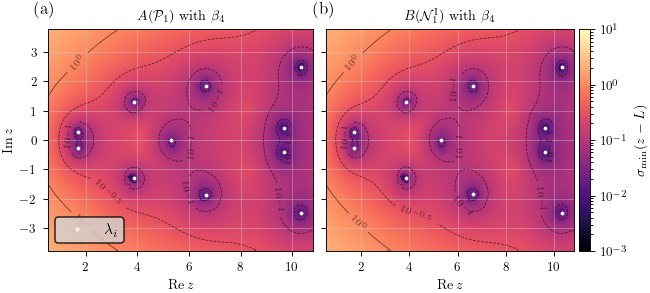

In [17]:
# Use the full text width and a height that gives each panel a roughly square aspect ratio
fig_height = fig_width * 0.45 
wind = 'b4'
with matplotlib.rc_context(PS_RC):
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height), sharey=True)
    
    # White markers contrast perfectly against the dark valleys of the magma colormap
    marker_style = {"color": "white", "markersize": 3} 
    
    # --- Left Panel: A(CG) ---
    ps.plot_pseudospectrum(
        results[("A(CG)", wind)], ax=axes[0],
        cmap="magma",
        title=r"$A(\mathcal{P}_1)$ with $\beta_4$",
        xlim=PS_AXES[wind][0], ylim=PS_AXES[wind][1],
        vmin=PS_SCALE[wind][0], vmax=PS_SCALE[wind][1],
        per_decade=2, grid=True, legend=True, colorbar=False,
        legend_kw={
            "frameon": True, 
            "facecolor": "lightgray",  # Sets the legend background to grey
            "edgecolor": "black",       # Adds a slightly darker border
            "loc": "lower left", 
            "fontsize": base_fontsize - 1
        },
        eig_kw=marker_style
    )
    
    # Explicitly capitalize the legend label
    if axes[0].get_legend():
        for text in axes[0].get_legend().get_texts():
            text.set_text(r"$\lambda_i$")
            
    axes[0].text(-0.05, 1.05, "(a)", transform=axes[0].transAxes, 
                 fontsize=base_fontsize, fontweight="bold", va="bottom")
    
    # --- Right Panel: B(N1) ---
    ps.plot_pseudospectrum(
        results[("B(N1)", wind)], ax=axes[1],
        cmap="magma",
        title=r"$B(\mathcal{N}^\mathrm{I}_1)$ with $\beta_4$",
        xlim=PS_AXES[wind][0], ylim=PS_AXES[wind][1],
        vmin=PS_SCALE[wind][0], vmax=PS_SCALE[wind][1],
        per_decade=2, grid=True, legend=False,
        colorbar_label=r"$\sigma_{\min}(z - L)$",
        colorbar_kw={"pad": 0.02, "fraction": 0.045},
        eig_kw=marker_style
    )
    
    axes[1].text(-0.05, 1.05, "(b)", transform=axes[1].transAxes, 
                 fontsize=base_fontsize, fontweight="bold", va="bottom")
    
    axes[1].set_ylabel("")
    plt.tight_layout(pad=0.1)
    fig.savefig(FIGDIR / "baseline_pseudo_b4_sidebyside.eps")
    plt.show()

# Appendix


## Figure A.1: B(N_p^I) convergence under h- and p-refinement (β0)


$B(\mathcal{N}^{\mathrm{I}}_p)$: $h$-refinement at $p=1$ and $p$-refinement at $N=6$ from the studies under Figure 4.1. Panels: `baseline_h_p1_BN1.eps`, `baseline_pref_BN1.eps`.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


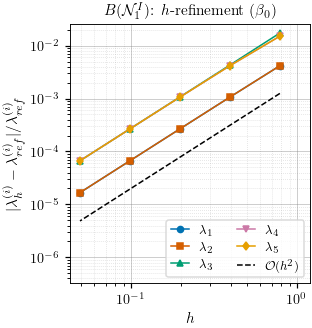

In [18]:
from matplotlib.ticker import LogLocator, NullFormatter
import numpy as np
import matplotlib.pyplot as plt

# 1. Give it a taller aspect ratio (square-ish) so the data has vertical room
half_width = fig_width * 0.49
half_height = half_width * 1.05 

df = h_eig[("B(N1)", 1)]
h = df["h"].to_numpy()
e1 = df[r"$\lambda_{1}$"].to_numpy()
e2 = df[r"$\lambda_{2}$"].to_numpy()
e3 = df[r"$\lambda_{3}$"].to_numpy()
e4 = df[r"$\lambda_{4}$"].to_numpy()
e5 = df[r"$\lambda_{5}$"].to_numpy()

colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']

fig, ax = plt.subplots(figsize=(half_width, half_height))

ax.loglog(h, e1, marker="o", color=colors[0], ms=4.0, lw=1.0, label=r"$\lambda_{1}$")
ax.loglog(h, e2, marker="s", color=colors[1], ms=4.0, lw=1.0, label=r"$\lambda_{2}$")
ax.loglog(h, e3, marker="^", color=colors[2], ms=4.0, lw=1.0, label=r"$\lambda_{3}$")
ax.loglog(h, e4, marker="v", color=colors[3], ms=4.0, lw=1.0, label=r"$\lambda_{4}$")
ax.loglog(h, e5, marker="d", color=colors[4], ms=4.0, lw=1.0, label=r"$\lambda_{5}$")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.0, label=r"$\mathcal{O}(h^{2})$")

# Flatten the y-label fraction and slightly reduce label font sizes for the subfigure
sub_fontsize = base_fontsize - 1 
ax.set_xlabel(r"$h$", fontsize=sub_fontsize)
ax.set_ylabel(r"$|\lambda_h^{(i)} - \lambda_{ref}^{(i)}| / \lambda_{ref}^{(i)}$", fontsize=sub_fontsize)

# Reverted the title pad back to default since the legend is moving back inside
ax.set_title(r"$B(\mathcal{N}^I_1)$: $h$-refinement ($\beta_0$)", fontsize=sub_fontsize)

ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

locmin = LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12)
ax.xaxis.set_minor_locator(locmin)
ax.xaxis.set_minor_formatter(NullFormatter())

# FORCE 10^0 ON X-AXIS: Extend the right limit slightly past 1.0 so the tick label isn't hidden
ax.set_xlim(right=1.2) 

# 2. Grabs the current limits and stretches the bottom down by a factor of 10
ymin, ymax = ax.get_ylim()
ax.set_ylim(bottom=ymin * 0.1) 

# 3. Compact the legend and tuck it into the newly created space in the lower right
ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray", 
          ncol=2, loc="lower right", handlelength=1.5, borderpad=0.4)

# 4. Use a smaller pad in tight_layout to maximize axis space
plt.tight_layout(pad=0.3)
fig.savefig(FIGDIR / "baseline_h_p1_BN1.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


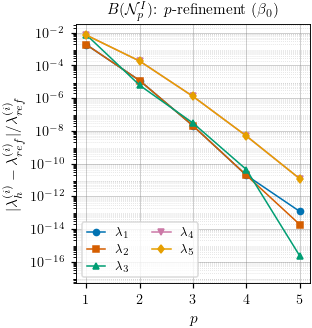

In [19]:
from matplotlib.ticker import LogLocator, NullFormatter

df = p_tables["B(N1)"]

colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']

fig, ax = plt.subplots(figsize=(half_width, half_height))

ax.semilogy(df.index, df[r"$\lambda_{1}$"], marker="o", color=colors[0], ms=4.0, lw=1.0, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[r"$\lambda_{2}$"], marker="s", color=colors[1], ms=4.0, lw=1.0, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[r"$\lambda_{3}$"], marker="^", color=colors[2], ms=4.0, lw=1.0, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[r"$\lambda_{4}$"], marker="v", color=colors[3], ms=4.0, lw=1.0, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[r"$\lambda_{5}$"], marker="d", color=colors[4], ms=4.0, lw=1.0, label=r"$\lambda_{5}$")

sub_fontsize = base_fontsize - 1 
ax.set_xlabel(r"$p$", fontsize=sub_fontsize)
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"$|\lambda_h^{(i)} - \lambda_{ref}^{(i)}| / \lambda_{ref}^{(i)}$", fontsize=sub_fontsize)

ax.set_title(rf"$B(\mathcal{{N}}^I_p)$: $p$-refinement ($\beta_0$)", fontsize=sub_fontsize)

ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

# Force y-axis minor ticks to display across a deep exponential drop
locmin = LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=40)
ax.yaxis.set_minor_locator(locmin)
ax.yaxis.set_minor_formatter(NullFormatter())

ymin, ymax = ax.get_ylim()
ax.set_ylim(bottom=ymin * 0.1) 

ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray", 
          ncol=2, loc="lower left", handlelength=1.5, borderpad=0.4)

plt.tight_layout(pad=0.3)
fig.savefig(FIGDIR / "baseline_pref_BN1.eps")
plt.show()

## Figure A.2: B(N_p^II) convergence under h- and p-refinement (β0)


$B(\mathcal{N}^{\mathrm{II}}_p)$: $h$-refinement at $p=1$ and $p$-refinement at $N=6$ from the studies under Figure 4.1. Panels: `baseline_h_p1_BN2.eps`, `baseline_pref_BN2.eps`.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


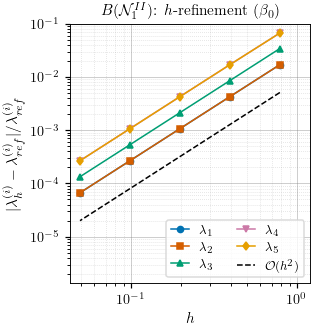

In [20]:
from matplotlib.ticker import LogLocator, NullFormatter
import numpy as np
import matplotlib.pyplot as plt

# 1. Give it a taller aspect ratio (square-ish) so the data has vertical room
half_width = fig_width * 0.49
half_height = half_width * 1.05 

df = h_eig[("B(N2)", 1)]
h = df["h"].to_numpy()
e1 = df[r"$\lambda_{1}$"].to_numpy()
e2 = df[r"$\lambda_{2}$"].to_numpy()
e3 = df[r"$\lambda_{3}$"].to_numpy()
e4 = df[r"$\lambda_{4}$"].to_numpy()
e5 = df[r"$\lambda_{5}$"].to_numpy()

colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']

fig, ax = plt.subplots(figsize=(half_width, half_height))

ax.loglog(h, e1, marker="o", color=colors[0], ms=4.0, lw=1.0, label=r"$\lambda_{1}$")
ax.loglog(h, e2, marker="s", color=colors[1], ms=4.0, lw=1.0, label=r"$\lambda_{2}$")
ax.loglog(h, e3, marker="^", color=colors[2], ms=4.0, lw=1.0, label=r"$\lambda_{3}$")
ax.loglog(h, e4, marker="v", color=colors[3], ms=4.0, lw=1.0, label=r"$\lambda_{4}$")
ax.loglog(h, e5, marker="d", color=colors[4], ms=4.0, lw=1.0, label=r"$\lambda_{5}$")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.0, label=r"$\mathcal{O}(h^{2})$")

# Flatten the y-label fraction and slightly reduce label font sizes for the subfigure
sub_fontsize = base_fontsize - 1 
ax.set_xlabel(r"$h$", fontsize=sub_fontsize)
ax.set_ylabel(r"$|\lambda_h^{(i)} - \lambda_{ref}^{(i)}| / \lambda_{ref}^{(i)}$", fontsize=sub_fontsize)

# Reverted the title pad back to default since the legend is moving back inside
ax.set_title(r"$B(\mathcal{N}^{II}_1)$: $h$-refinement ($\beta_0$)", fontsize=sub_fontsize)

ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

locmin = LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12)
ax.xaxis.set_minor_locator(locmin)
ax.xaxis.set_minor_formatter(NullFormatter())

# FORCE 10^0 ON X-AXIS: Extend the right limit slightly past 1.0 so the tick label isn't hidden
ax.set_xlim(right=1.2) 

# 2. Grabs the current limits and stretches the bottom down by a factor of 10
ymin, ymax = ax.get_ylim()
ax.set_ylim(bottom=ymin * 0.1) 

# 3. Compact the legend and tuck it into the newly created space in the lower right
ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray", 
          ncol=2, loc="lower right", handlelength=1.5, borderpad=0.4)

# 4. Use a smaller pad in tight_layout to maximize axis space
plt.tight_layout(pad=0.3)
fig.savefig(FIGDIR / "baseline_h_p1_BN2.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


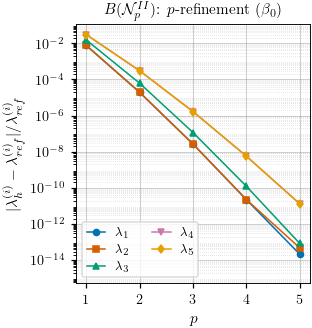

In [21]:
from matplotlib.ticker import LogLocator, NullFormatter

df = p_tables["B(N2)"]

colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']

fig, ax = plt.subplots(figsize=(half_width, half_height))

ax.semilogy(df.index, df[r"$\lambda_{1}$"], marker="o", color=colors[0], ms=4.0, lw=1.0, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[r"$\lambda_{2}$"], marker="s", color=colors[1], ms=4.0, lw=1.0, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[r"$\lambda_{3}$"], marker="^", color=colors[2], ms=4.0, lw=1.0, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[r"$\lambda_{4}$"], marker="v", color=colors[3], ms=4.0, lw=1.0, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[r"$\lambda_{5}$"], marker="d", color=colors[4], ms=4.0, lw=1.0, label=r"$\lambda_{5}$")

sub_fontsize = base_fontsize - 1 
ax.set_xlabel(r"$p$", fontsize=sub_fontsize)
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"$|\lambda_h^{(i)} - \lambda_{ref}^{(i)}| / \lambda_{ref}^{(i)}$", fontsize=sub_fontsize)

ax.set_title(r"$B(\mathcal{{N}}^{II}_p)$: $p$-refinement ($\beta_0$)", fontsize=sub_fontsize)

ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

# Force y-axis minor ticks to display across a deep exponential drop
locmin = LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=40)
ax.yaxis.set_minor_locator(locmin)
ax.yaxis.set_minor_formatter(NullFormatter())

ymin, ymax = ax.get_ylim()
ax.set_ylim(bottom=ymin * 0.1) 

ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray", 
          ncol=2, loc="lower left", handlelength=1.5, borderpad=0.4)

plt.tight_layout(pad=0.3)
fig.savefig(FIGDIR / "baseline_pref_BN2.eps")
plt.show()

## Figure A.3: 1-form pseudospectra under β1


Side-by-side pseudospectra for $\beta_1=(1,1)$ from the results computed under Figure 4.2 ($R_m=1$, $N=32$, $p=1$, $\tau=0.9$, 100 eigenvalues): `baseline_pseudo_b1_sidebyside.eps` (parameter re-run of the $\beta_5$ cell).


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


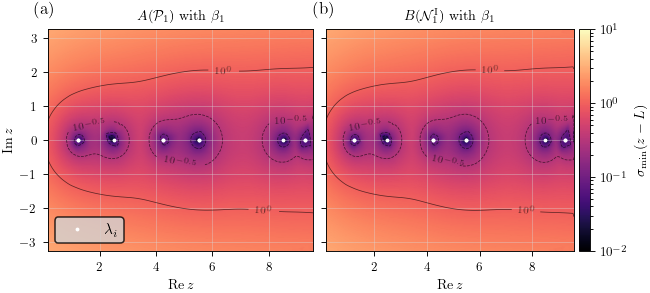

In [22]:
# Use the full text width and a height that gives each panel a roughly square aspect ratio
fig_height = fig_width * 0.45 
wind = 'b1'
with matplotlib.rc_context(PS_RC):
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height), sharey=True)
    
    # White markers contrast perfectly against the dark valleys of the magma colormap
    marker_style = {"color": "white", "markersize": 3} 
    
    # --- Left Panel: A(CG) ---
    ps.plot_pseudospectrum(
        results[("A(CG)", wind)], ax=axes[0],
        cmap="magma",
        title=r"$A(\mathcal{P}_1)$ with $\beta_1$",
        xlim=PS_AXES[wind][0], ylim=PS_AXES[wind][1],
        vmin=PS_SCALE[wind][0], vmax=PS_SCALE[wind][1],
        per_decade=2, grid=True, legend=True, colorbar=False,
        legend_kw={
            "frameon": True, 
            "facecolor": "lightgray",  # Sets the legend background to grey
            "edgecolor": "black",       # Adds a slightly darker border
            "loc": "lower left", 
            "fontsize": base_fontsize - 1
        },
        eig_kw=marker_style
    )
    
    # Explicitly capitalize the legend label
    if axes[0].get_legend():
        for text in axes[0].get_legend().get_texts():
            text.set_text(r"$\lambda_i$")
            
    axes[0].text(-0.05, 1.05, "(a)", transform=axes[0].transAxes, 
                 fontsize=base_fontsize, fontweight="bold", va="bottom")
    
    # --- Right Panel: B(N1) ---
    ps.plot_pseudospectrum(
        results[("B(N1)", wind)], ax=axes[1],
        cmap="magma",
        title=r"$B(\mathcal{N}^\mathrm{I}_1)$ with $\beta_1$",
        xlim=PS_AXES[wind][0], ylim=PS_AXES[wind][1],
        vmin=PS_SCALE[wind][0], vmax=PS_SCALE[wind][1],
        per_decade=2, grid=True, legend=False,
        colorbar_label=r"$\sigma_{\min}(z - L)$",
        colorbar_kw={"pad": 0.02, "fraction": 0.045},
        eig_kw=marker_style
    )
    
    axes[1].text(-0.05, 1.05, "(b)", transform=axes[1].transAxes, 
                 fontsize=base_fontsize, fontweight="bold", va="bottom")
    
    axes[1].set_ylabel("")
    plt.tight_layout(pad=0.1)
    fig.savefig(FIGDIR / "baseline_pseudo_b1_sidebyside.eps")
    plt.show()

## Figure A.4: 1-form pseudospectra under β2


Side-by-side pseudospectra for $\beta_2=(x,-y)$, same parameters: `baseline_pseudo_b2_sidebyside.eps` (parameter re-run of the $\beta_5$ cell).


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


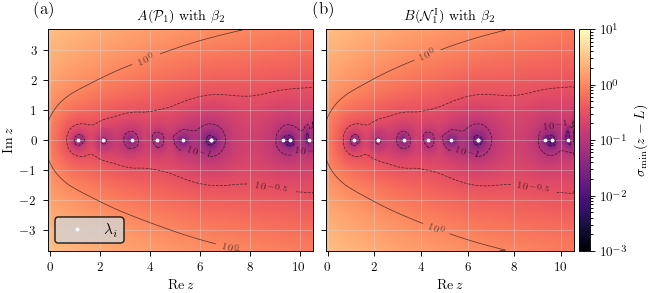

In [23]:
# Use the full text width and a height that gives each panel a roughly square aspect ratio
fig_height = fig_width * 0.45 
wind = 'b2'
with matplotlib.rc_context(PS_RC):
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height), sharey=True)
    
    # White markers contrast perfectly against the dark valleys of the magma colormap
    marker_style = {"color": "white", "markersize": 3} 
    
    # --- Left Panel: A(CG) ---
    ps.plot_pseudospectrum(
        results[("A(CG)", wind)], ax=axes[0],
        cmap="magma",
        title=r"$A(\mathcal{P}_1)$ with $\beta_2$",
        xlim=PS_AXES[wind][0], ylim=PS_AXES[wind][1],
        vmin=PS_SCALE[wind][0], vmax=PS_SCALE[wind][1],
        per_decade=2, grid=True, legend=True, colorbar=False,
        legend_kw={
            "frameon": True, 
            "facecolor": "lightgray",  # Sets the legend background to grey
            "edgecolor": "black",       # Adds a slightly darker border
            "loc": "lower left", 
            "fontsize": base_fontsize - 1
        },
        eig_kw=marker_style
    )
    
    # Explicitly capitalize the legend label
    if axes[0].get_legend():
        for text in axes[0].get_legend().get_texts():
            text.set_text(r"$\lambda_i$")
            
    axes[0].text(-0.05, 1.05, "(a)", transform=axes[0].transAxes, 
                 fontsize=base_fontsize, fontweight="bold", va="bottom")
    
    # --- Right Panel: B(N1) ---
    ps.plot_pseudospectrum(
        results[("B(N1)", wind)], ax=axes[1],
        cmap="magma",
        title=r"$B(\mathcal{N}^\mathrm{I}_1)$ with $\beta_2$",
        xlim=PS_AXES[wind][0], ylim=PS_AXES[wind][1],
        vmin=PS_SCALE[wind][0], vmax=PS_SCALE[wind][1],
        per_decade=2, grid=True, legend=False,
        colorbar_label=r"$\sigma_{\min}(z - L)$",
        colorbar_kw={"pad": 0.02, "fraction": 0.045},
        eig_kw=marker_style
    )
    
    axes[1].text(-0.05, 1.05, "(b)", transform=axes[1].transAxes, 
                 fontsize=base_fontsize, fontweight="bold", va="bottom")
    
    axes[1].set_ylabel("")
    plt.tight_layout(pad=0.1)
    fig.savefig(FIGDIR / "baseline_pseudo_b2_sidebyside.eps")
    plt.show()

## Figure A.5: 1-form pseudospectra under β5


Side-by-side pseudospectra for $\beta_5=(x+y,xy)$, same parameters: `baseline_pseudo_b5_sidebyside.eps`. This is the cell as saved in the source notebook, with its stored output.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


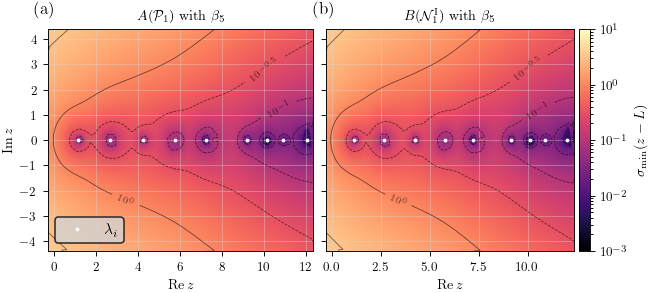

In [24]:
# Use the full text width and a height that gives each panel a roughly square aspect ratio
fig_height = fig_width * 0.45 
wind = 'b5'
with matplotlib.rc_context(PS_RC):
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height), sharey=True)
    
    # White markers contrast perfectly against the dark valleys of the magma colormap
    marker_style = {"color": "white", "markersize": 3} 
    
    # --- Left Panel: A(CG) ---
    ps.plot_pseudospectrum(
        results[("A(CG)", wind)], ax=axes[0],
        cmap="magma",
        title=r"$A(\mathcal{P}_1)$ with $\beta_5$",
        xlim=PS_AXES[wind][0], ylim=PS_AXES[wind][1],
        vmin=PS_SCALE[wind][0], vmax=PS_SCALE[wind][1],
        per_decade=2, grid=True, legend=True, colorbar=False,
        legend_kw={
            "frameon": True, 
            "facecolor": "lightgray",  # Sets the legend background to grey
            "edgecolor": "black",       # Adds a slightly darker border
            "loc": "lower left", 
            "fontsize": base_fontsize - 1
        },
        eig_kw=marker_style
    )
    
    # Explicitly capitalize the legend label
    if axes[0].get_legend():
        for text in axes[0].get_legend().get_texts():
            text.set_text(r"$\lambda_i$")
            
    axes[0].text(-0.05, 1.05, "(a)", transform=axes[0].transAxes, 
                 fontsize=base_fontsize, fontweight="bold", va="bottom")
    
    # --- Right Panel: B(N1) ---
    ps.plot_pseudospectrum(
        results[("B(N1)", wind)], ax=axes[1],
        cmap="magma",
        title=r"$B(\mathcal{N}^\mathrm{I}_1)$ with $\beta_5$",
        xlim=PS_AXES[wind][0], ylim=PS_AXES[wind][1],
        vmin=PS_SCALE[wind][0], vmax=PS_SCALE[wind][1],
        per_decade=2, grid=True, legend=False,
        colorbar_label=r"$\sigma_{\min}(z - L)$",
        colorbar_kw={"pad": 0.02, "fraction": 0.045},
        eig_kw=marker_style
    )
    
    axes[1].text(-0.05, 1.05, "(b)", transform=axes[1].transAxes, 
                 fontsize=base_fontsize, fontweight="bold", va="bottom")
    
    axes[1].set_ylabel("")
    plt.tight_layout(pad=0.1)
    fig.savefig(FIGDIR / "baseline_pseudo_b5_sidebyside.eps")
    plt.show()

## Notes

**Parameter re-runs.** `baseline.ipynb[27]` (side-by-side pseudospectrum) is saved with `wind = 'b5'`; the
b4 (Figure 4.2), b1 (Figure A.3) and b2 (Figure A.4) panels are the same cell with the wind key, the two
panel titles (`$\beta_5$`) and the output file name changed. Only the b5 copy carries a stored output.
The thesis file `baseline_pseudo_b4_sidebyside.eps` predates the saved notebook (29 vs. 31 August session), so the
b4 panel is a reconstruction from the b5 cell and may differ from the printed figure in minor styling.

**Caveats.** (a) Table 4.3 in the thesis prints $\lambda_h$ to 14 decimals, the stored output (cell under
Table 4.3, second cell) to 15; the thesis entries carry one zero fewer after the decimal point (e.g.
$1.00000000006576$ vs. stored $1.000000000006576$) and differ in the last one or two digits at the $10^{-14}$
level (a separate run), while DoF and `COND1` agree exactly. (b) The Figure 4.1 caption quotes
$\kappa_1(A-\tau M)<10^3$ for $A(\mathcal{P}_p)$ and Figures A.1/A.2 quote $<10^5$ for the $B$ formulations;
the `COND1` columns of the study tables are the record for these. (c) The $p=2$ $h$-study is computed by the
study cell for all formulations but no thesis figure uses it.

**Dropped.** `baseline.ipynb[28]`-`[30]`: pseudospectra recomputed at $R_m=10$ and a 1x3 $\beta_4$ figure
(`baseline_pseudo_b4_1x3.eps`) not in the thesis; `[31]` empty; source markdown cells replaced by the headings
above.
